In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.decomposition import PCA, KernelPCA
from sklearn.feature_selection import RFE
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import MDS, TSNE
from umap import UMAP

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import os
import umap
import io

In [22]:
from manifold_learning import *
from itertools import product

In [ ]:
os.makedirs('./images', exist_ok=True)

THUMBNAIL_SIZE = (64, 64)  # unified size for all images -> 4096 pixels

def save_kernel_pca(
    spiral_density=3,
    spiral_steps=20,
    width=7,
    angle=0.5,
    roll_density=5
):
    fig = plt.figure(figsize=(12, 6))

    ax = fig.add_subplot(111)
    points, d = roll_generator(
        to_array=True,
        spiral_density=spiral_density,
        spiral_steps=spiral_steps,
        width=width,
        angle=angle,
        density=roll_density,
    )

    embedding = PCA(n_components=2)
    points_transformed = embedding.fit_transform(points)
    points_transformed_t = points_transformed.T

    ax.scatter(
        points_transformed_t[0], points_transformed_t[1], c=d, cmap=plt.cm.coolwarm
    )
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_title(f"PCA - projection to 2D")

    filename = f'./images/pca_sd{spiral_density}_ss{spiral_steps}_w{width}_a{angle}_rd{roll_density}.png'
    plt.savefig(filename)

    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    img = Image.open(buf).convert('L').resize(THUMBNAIL_SIZE)
    pixel_vector = np.array(img).flatten()

    plt.close(fig)

    return filename, pixel_vector

In [24]:
param_grid = {
    "spiral_density": [2, 4, 6],
    "spiral_steps": [20, 50, 100],
    "width": [5, 7, 10],
    "angle": [0.3, 0.5, 0.8],
    "roll_density": [3, 5, 8],
}

keys = param_grid.keys()
values = param_grid.values()

images = {}

for combo in product(*values):
    params = dict(zip(keys, combo))
    filename, image = save_kernel_pca(**params)
    images[filename] = image

In [25]:
X = np.array(list(images.values()))
X[0].min()

178

In [26]:
os.makedirs('./meta', exist_ok=True)

# Build data matrix
filenames = list(images.keys())
X = np.array(list(images.values())).astype(np.float32) / 255.0  # normalize to [0, 1]
print(f"Data matrix: {X.shape}")  # (243, 4096)

# Standardize for PCA stability
X_mean = X.mean(axis=0)
X_std = X.std(axis=0) + 1e-8
X_norm = (X - X_mean) / X_std

embeddings = {}

# 1. PCA
embeddings['PCA'] = PCA(n_components=2).fit_transform(X_norm)

# 2. t-SNE with 3 perplexities
for perp in [5, 30, 50]:
    embeddings[f't-SNE (perplexity={perp})'] = TSNE(
        n_components=2,
        perplexity=perp,
        random_state=42,
        init='pca',
    ).fit_transform(X_norm)

# 3. UMAP with 3 hyperparameter combinations
umap_configs = [
    {'n_neighbors': 5,  'min_dist': 0.1},
    {'n_neighbors': 15, 'min_dist': 0.3},
    {'n_neighbors': 30, 'min_dist': 0.8},
]
for cfg in umap_configs:
    key = f"UMAP (n_neighbors={cfg['n_neighbors']}, min_dist={cfg['min_dist']})"
    embeddings[key] = umap.UMAP(n_components=2, **cfg).fit_transform(X_norm)

print(f"Computed {len(embeddings)} embeddings")

Data matrix: (243, 4096)


C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Computed 7 embeddings


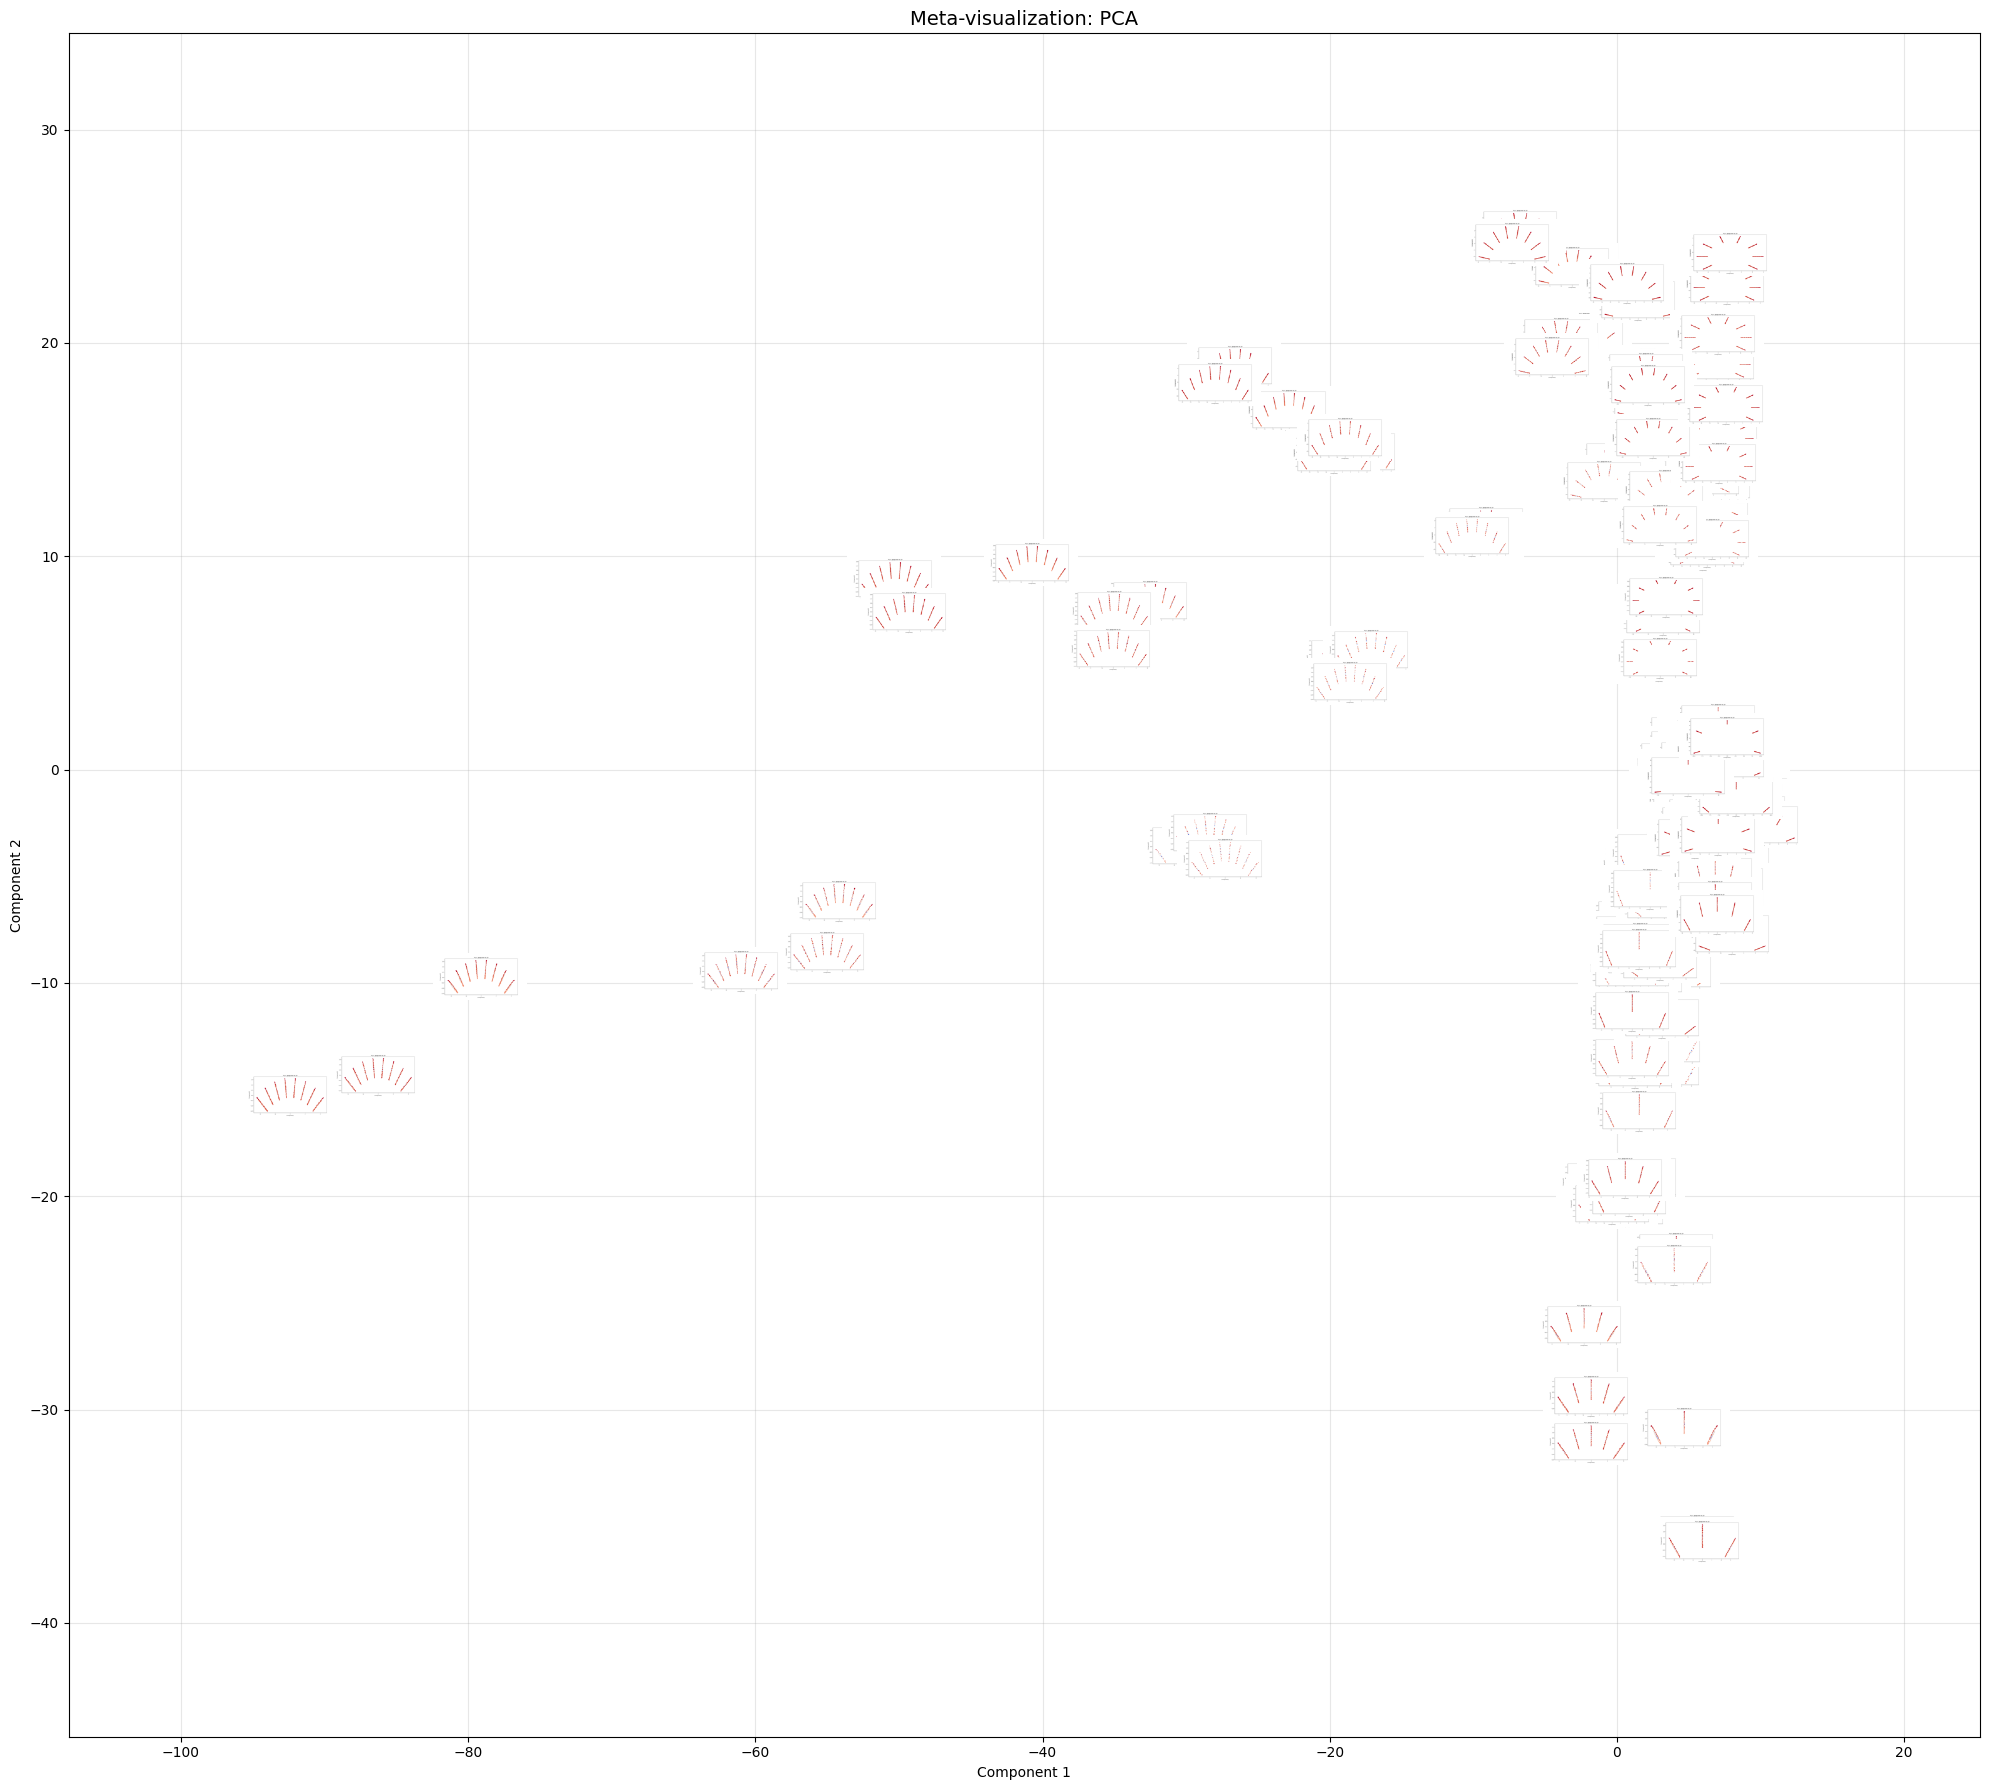

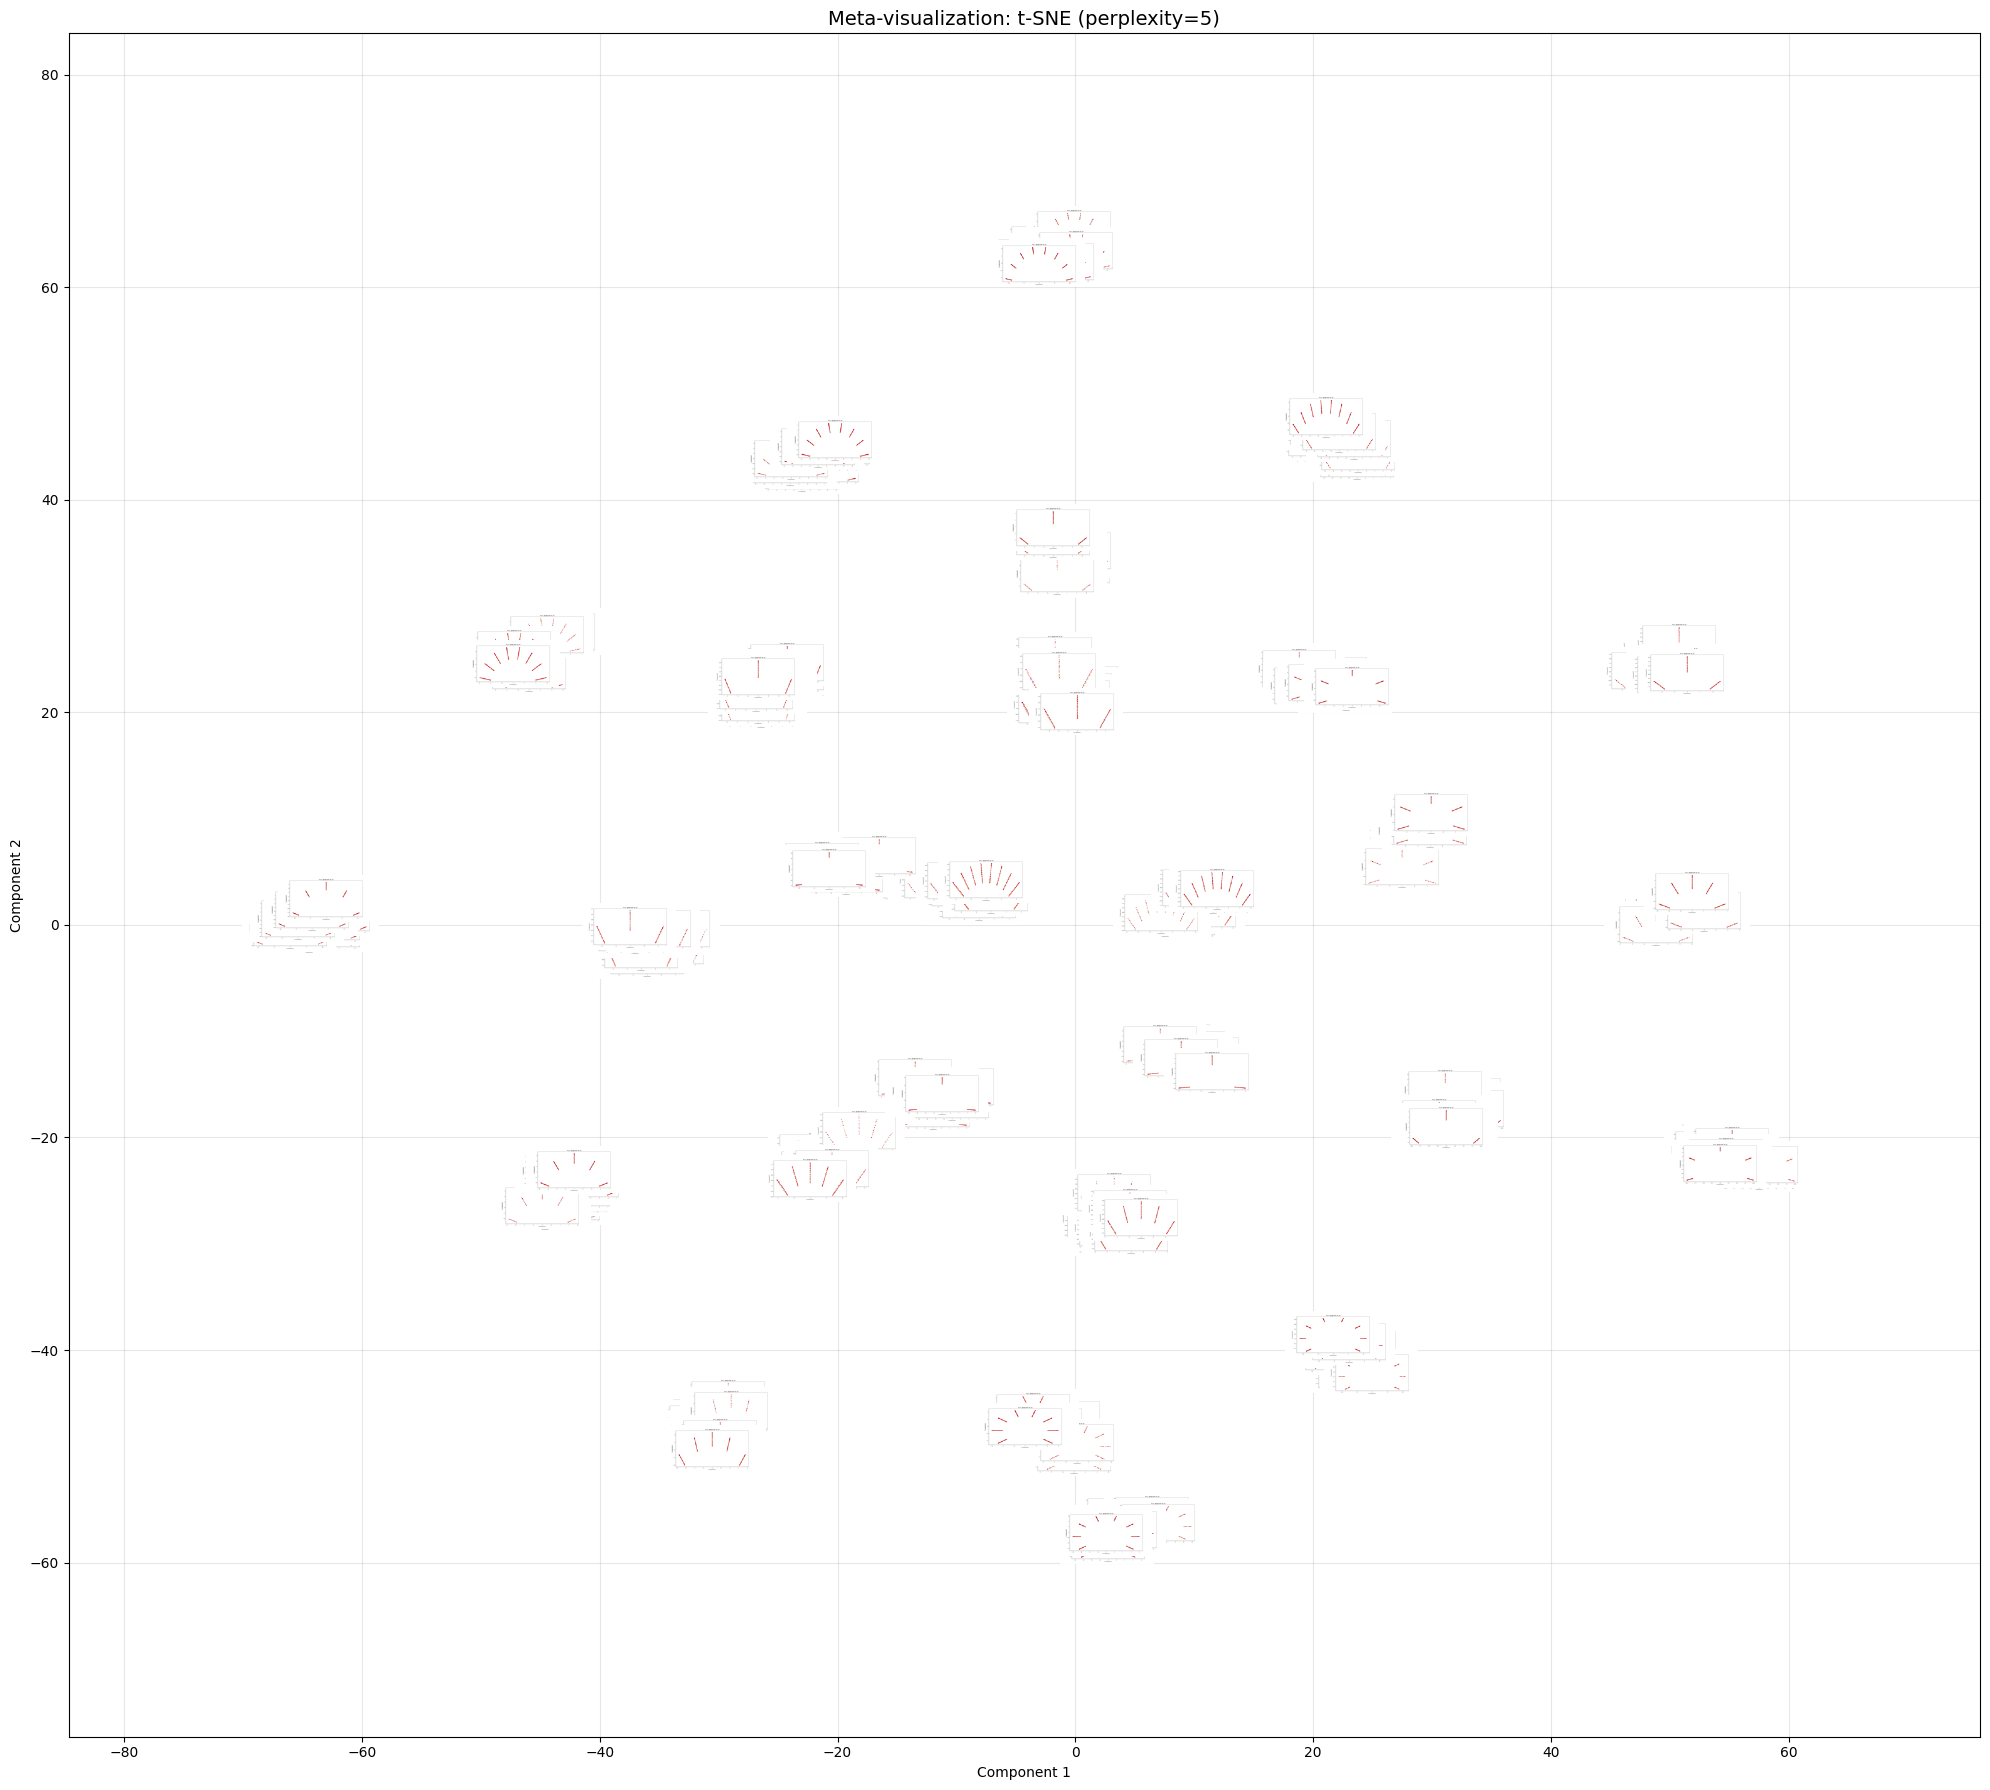

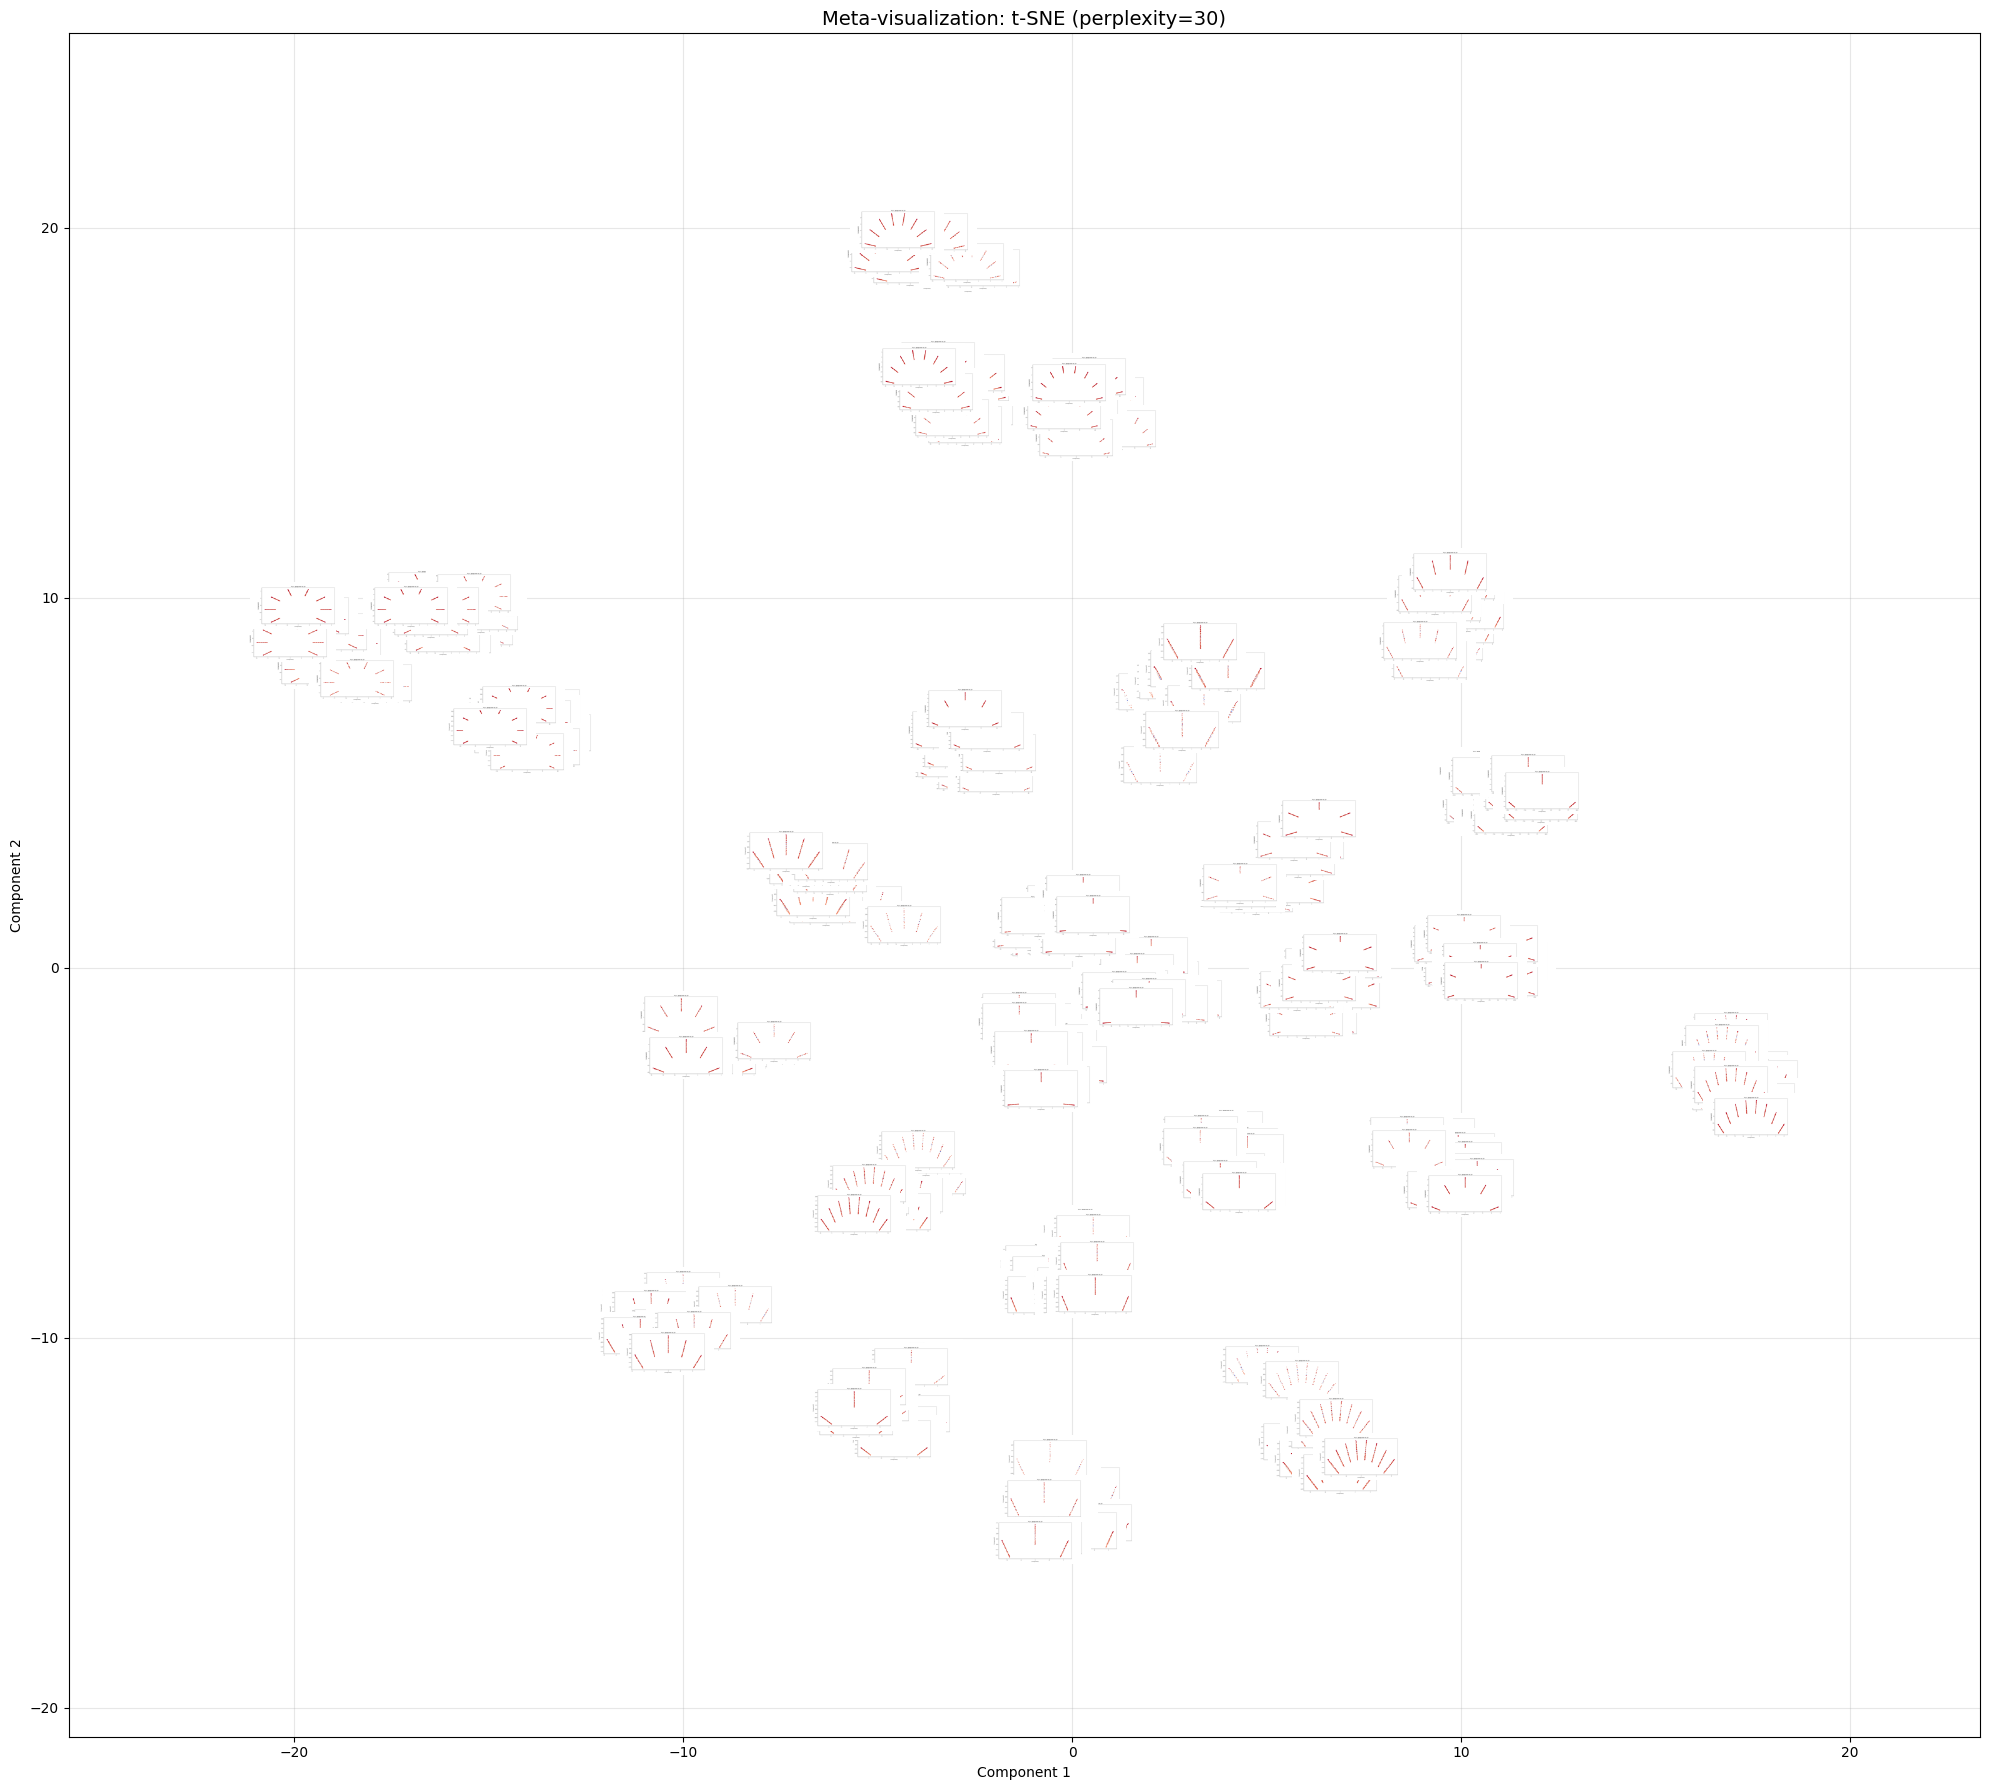

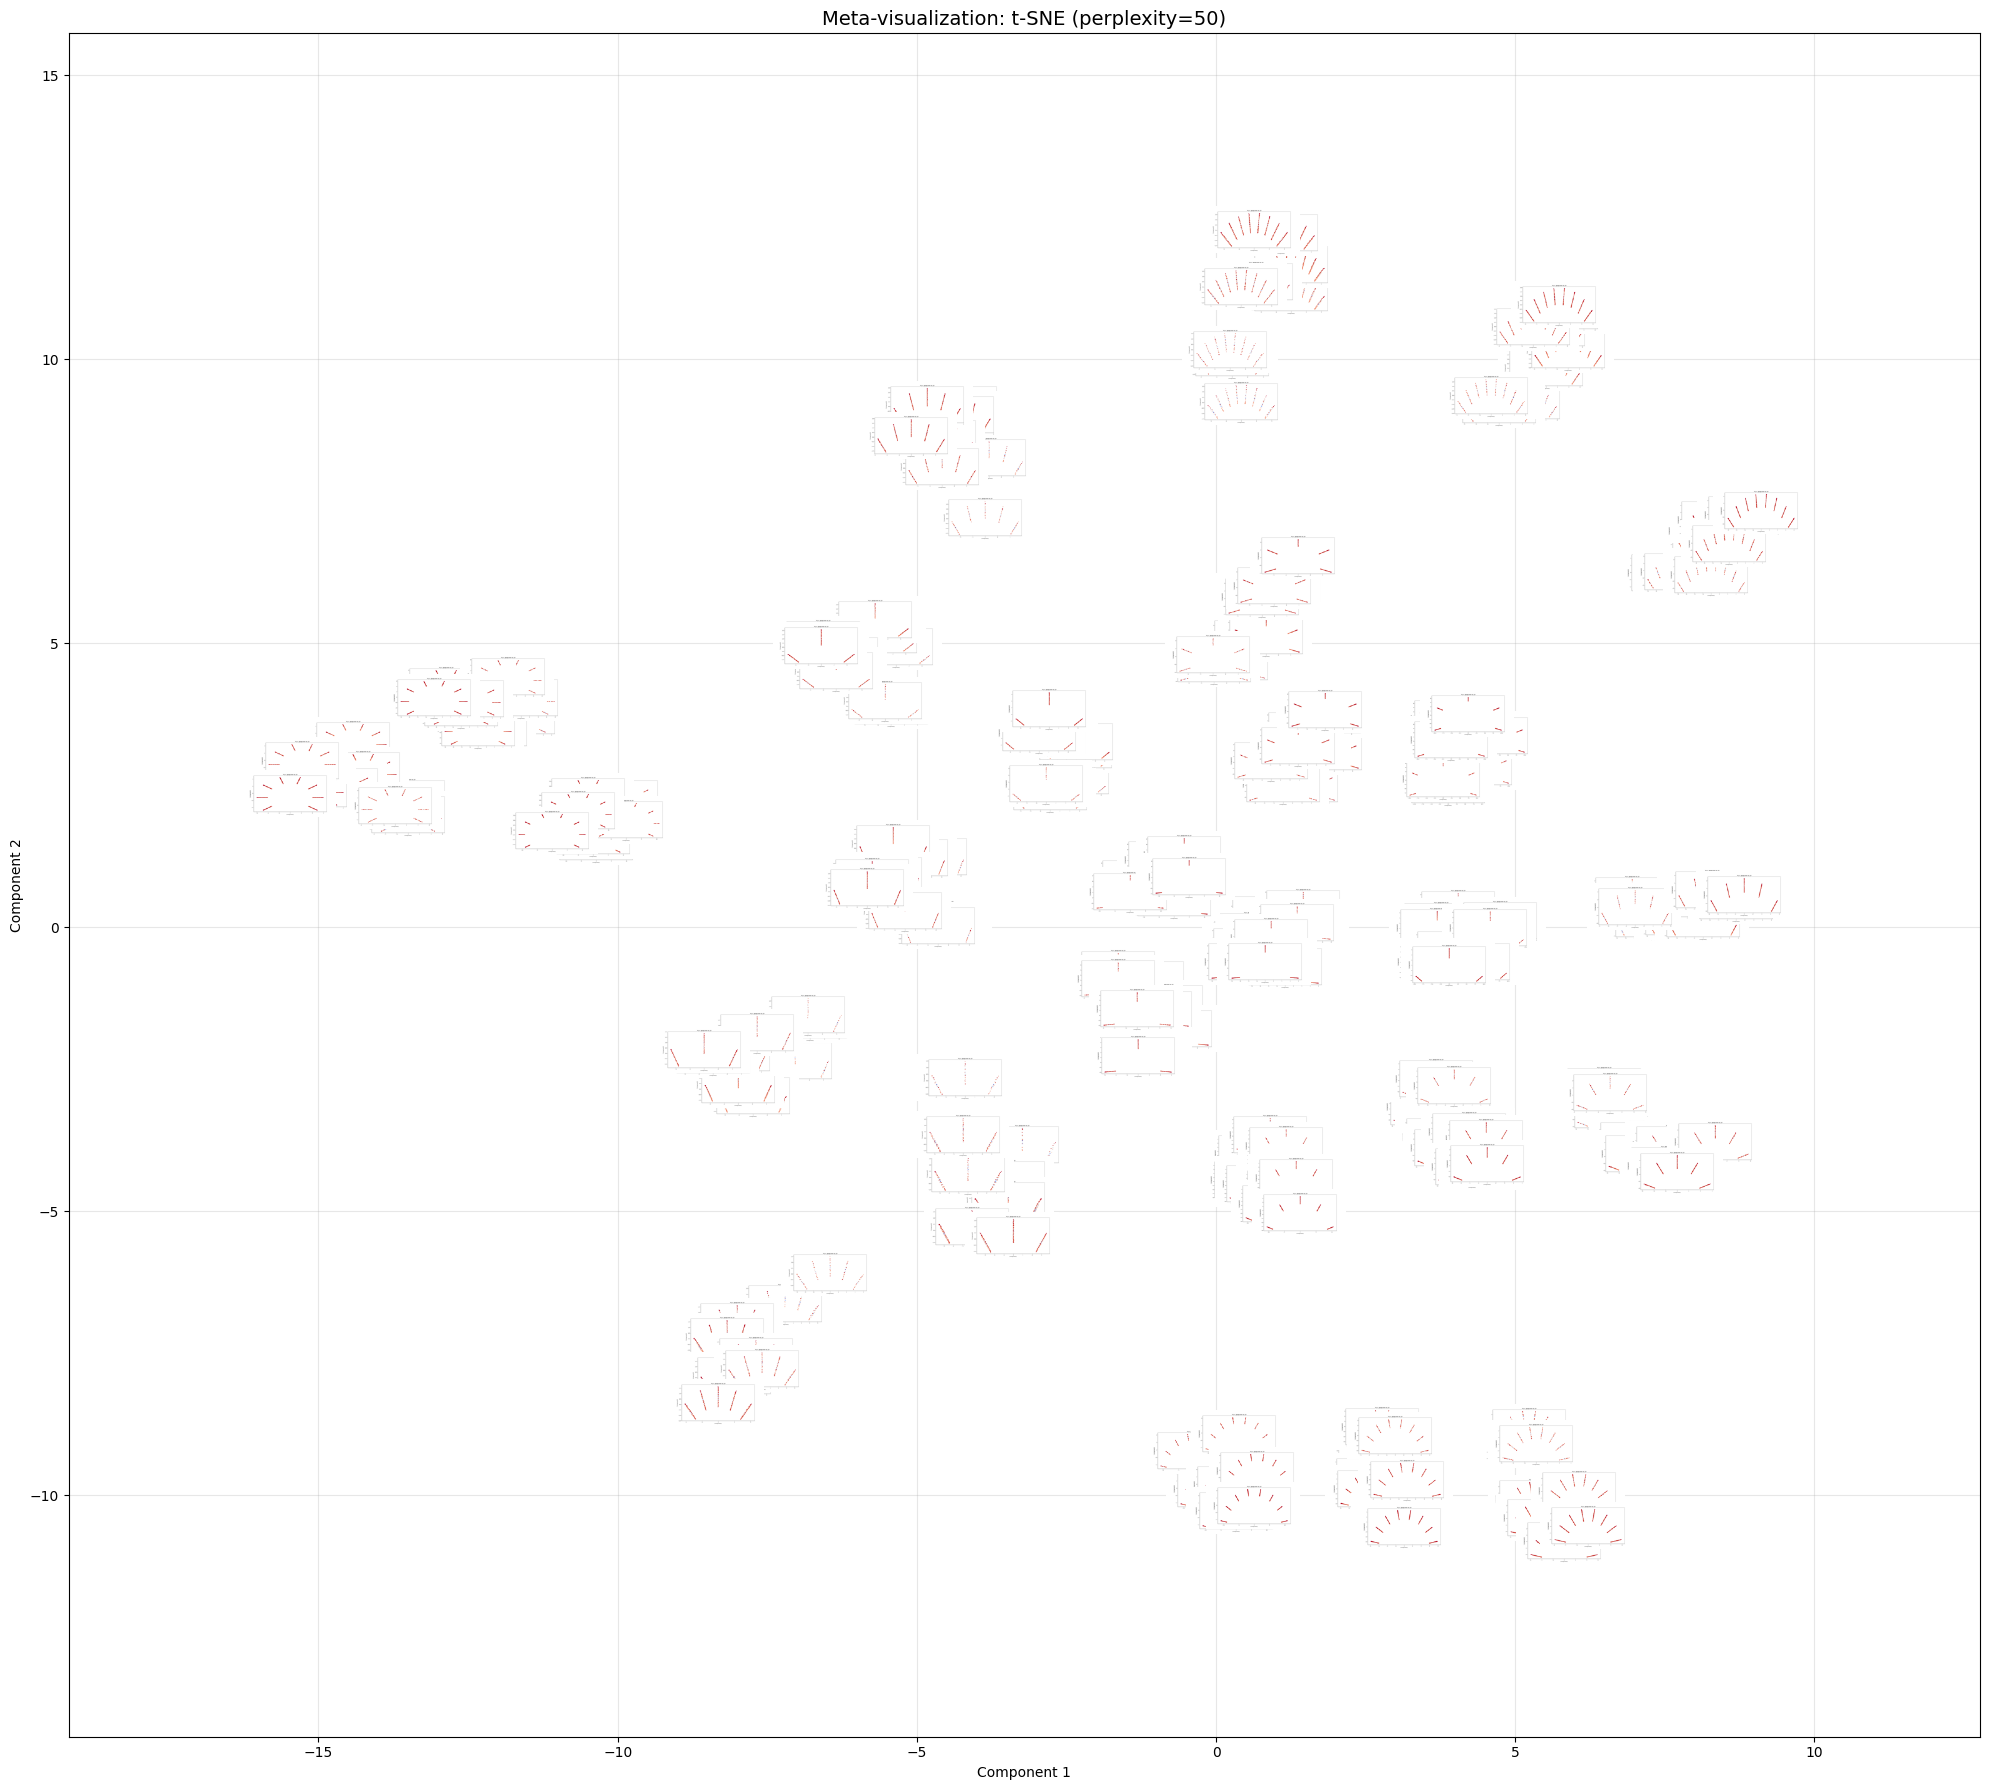

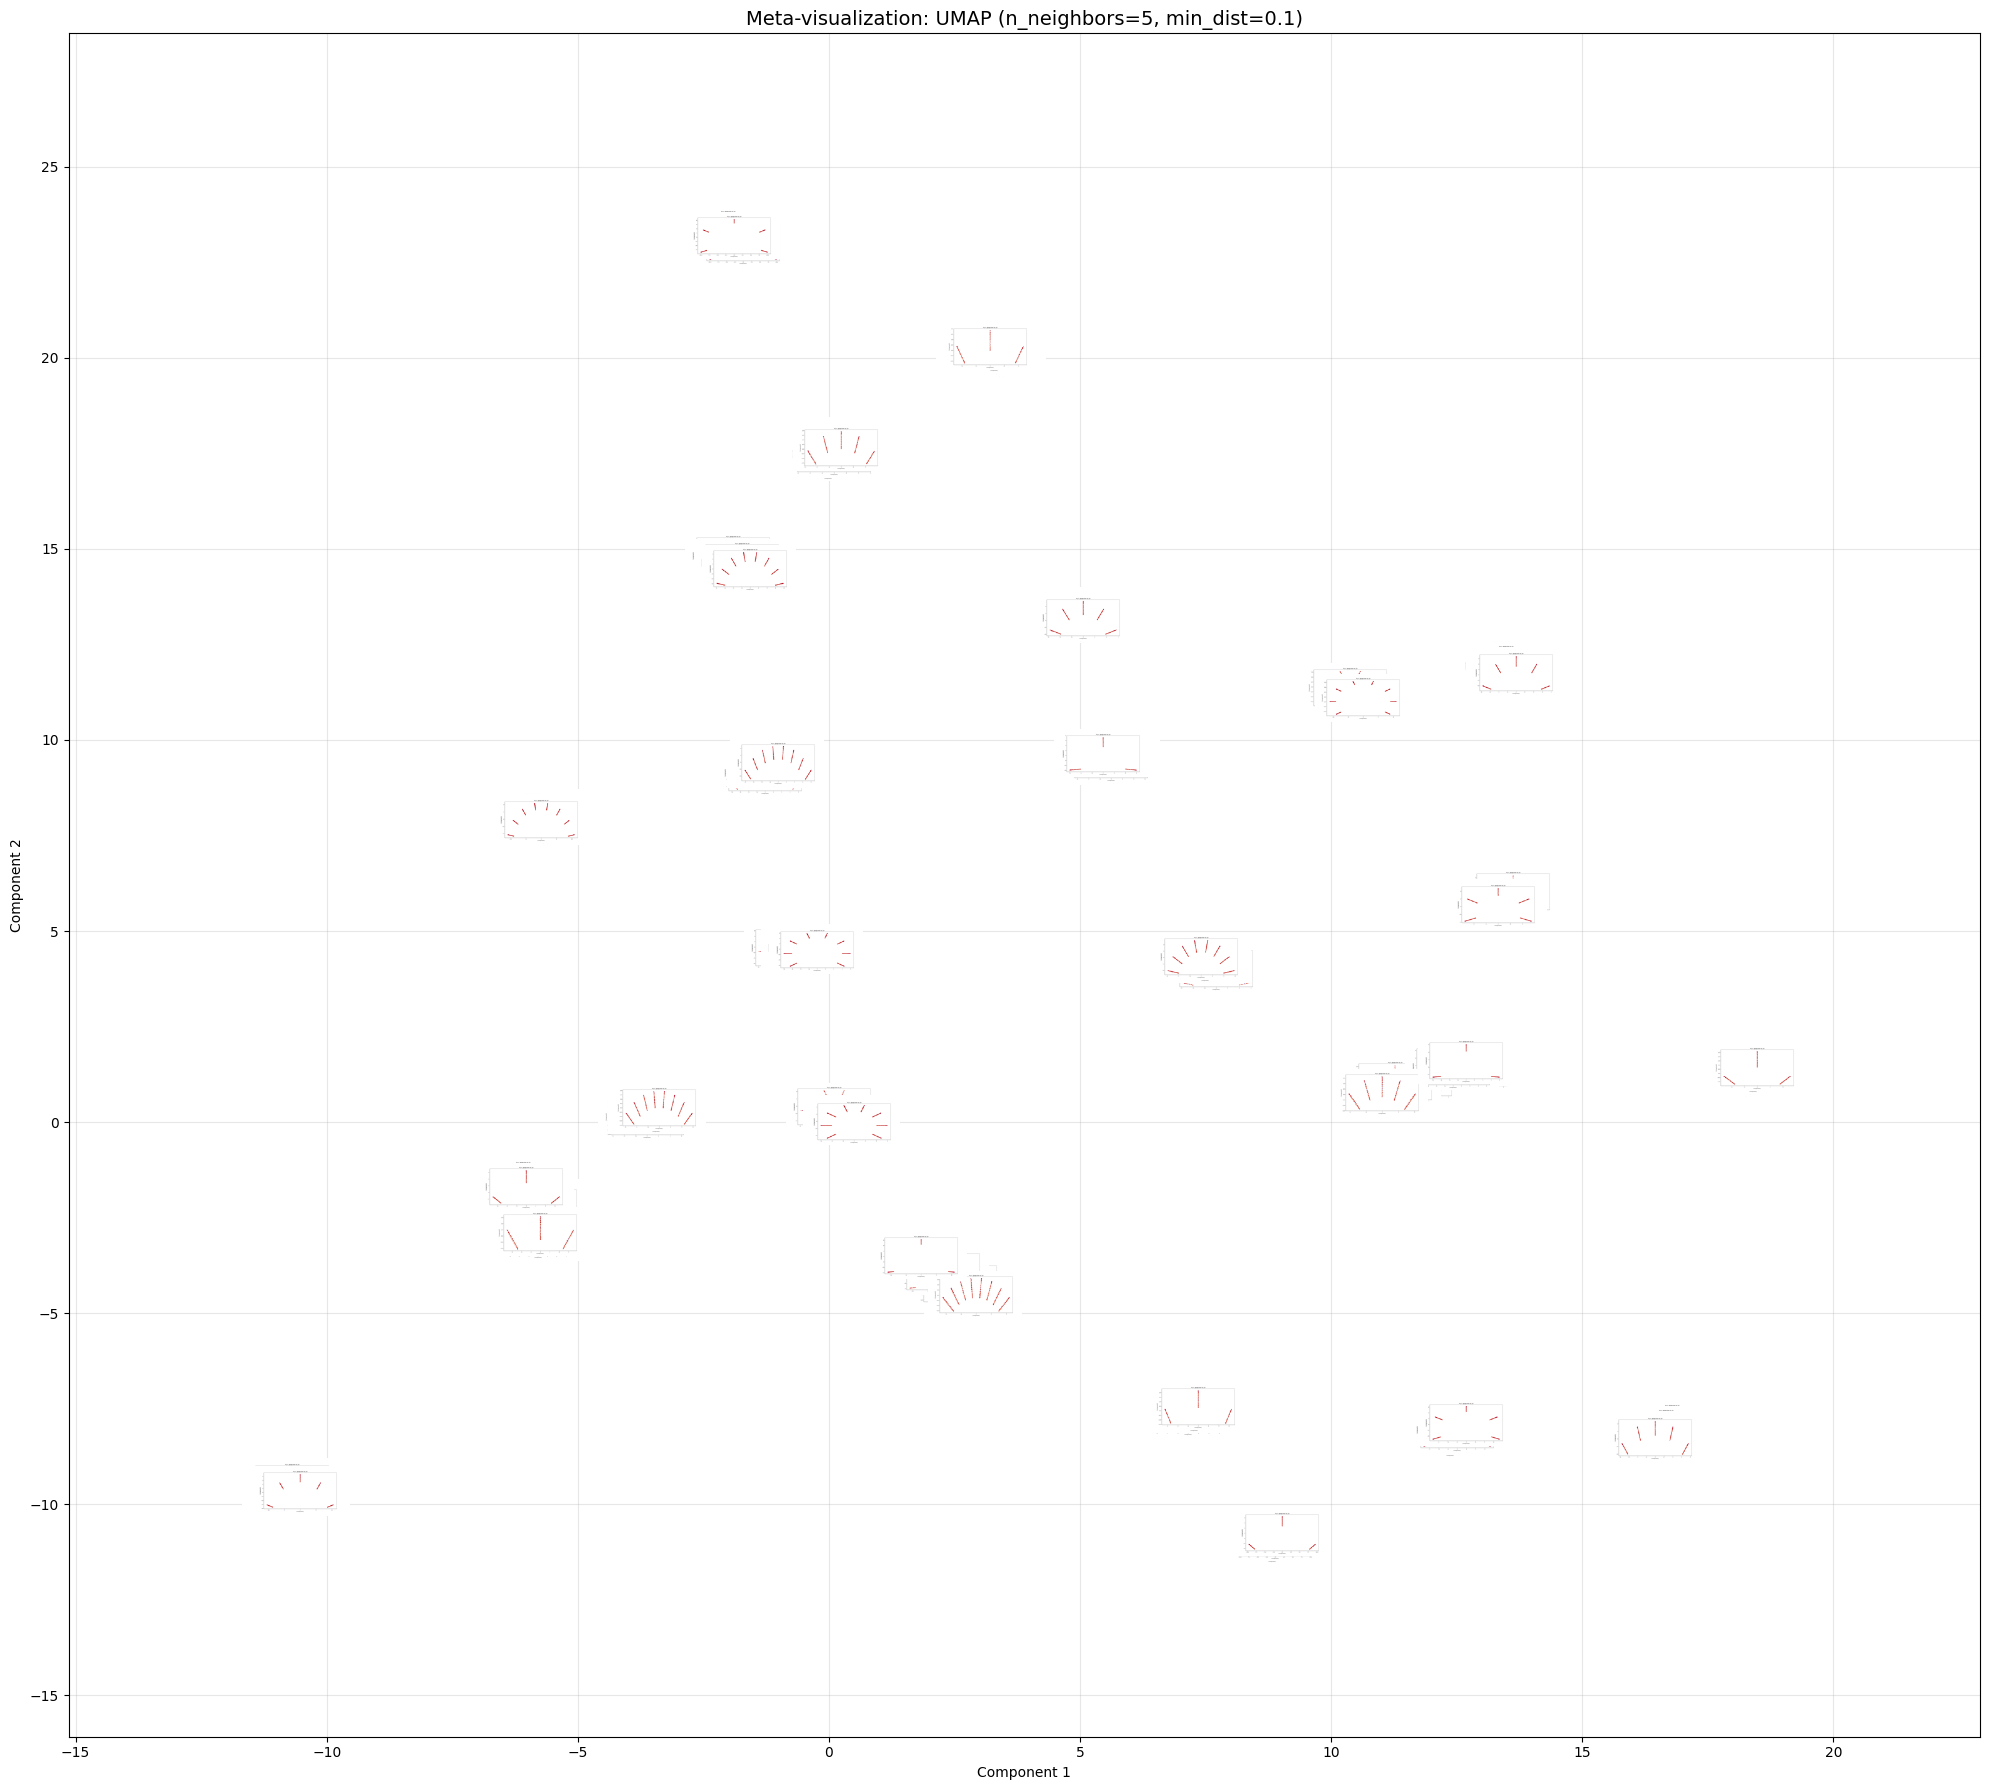

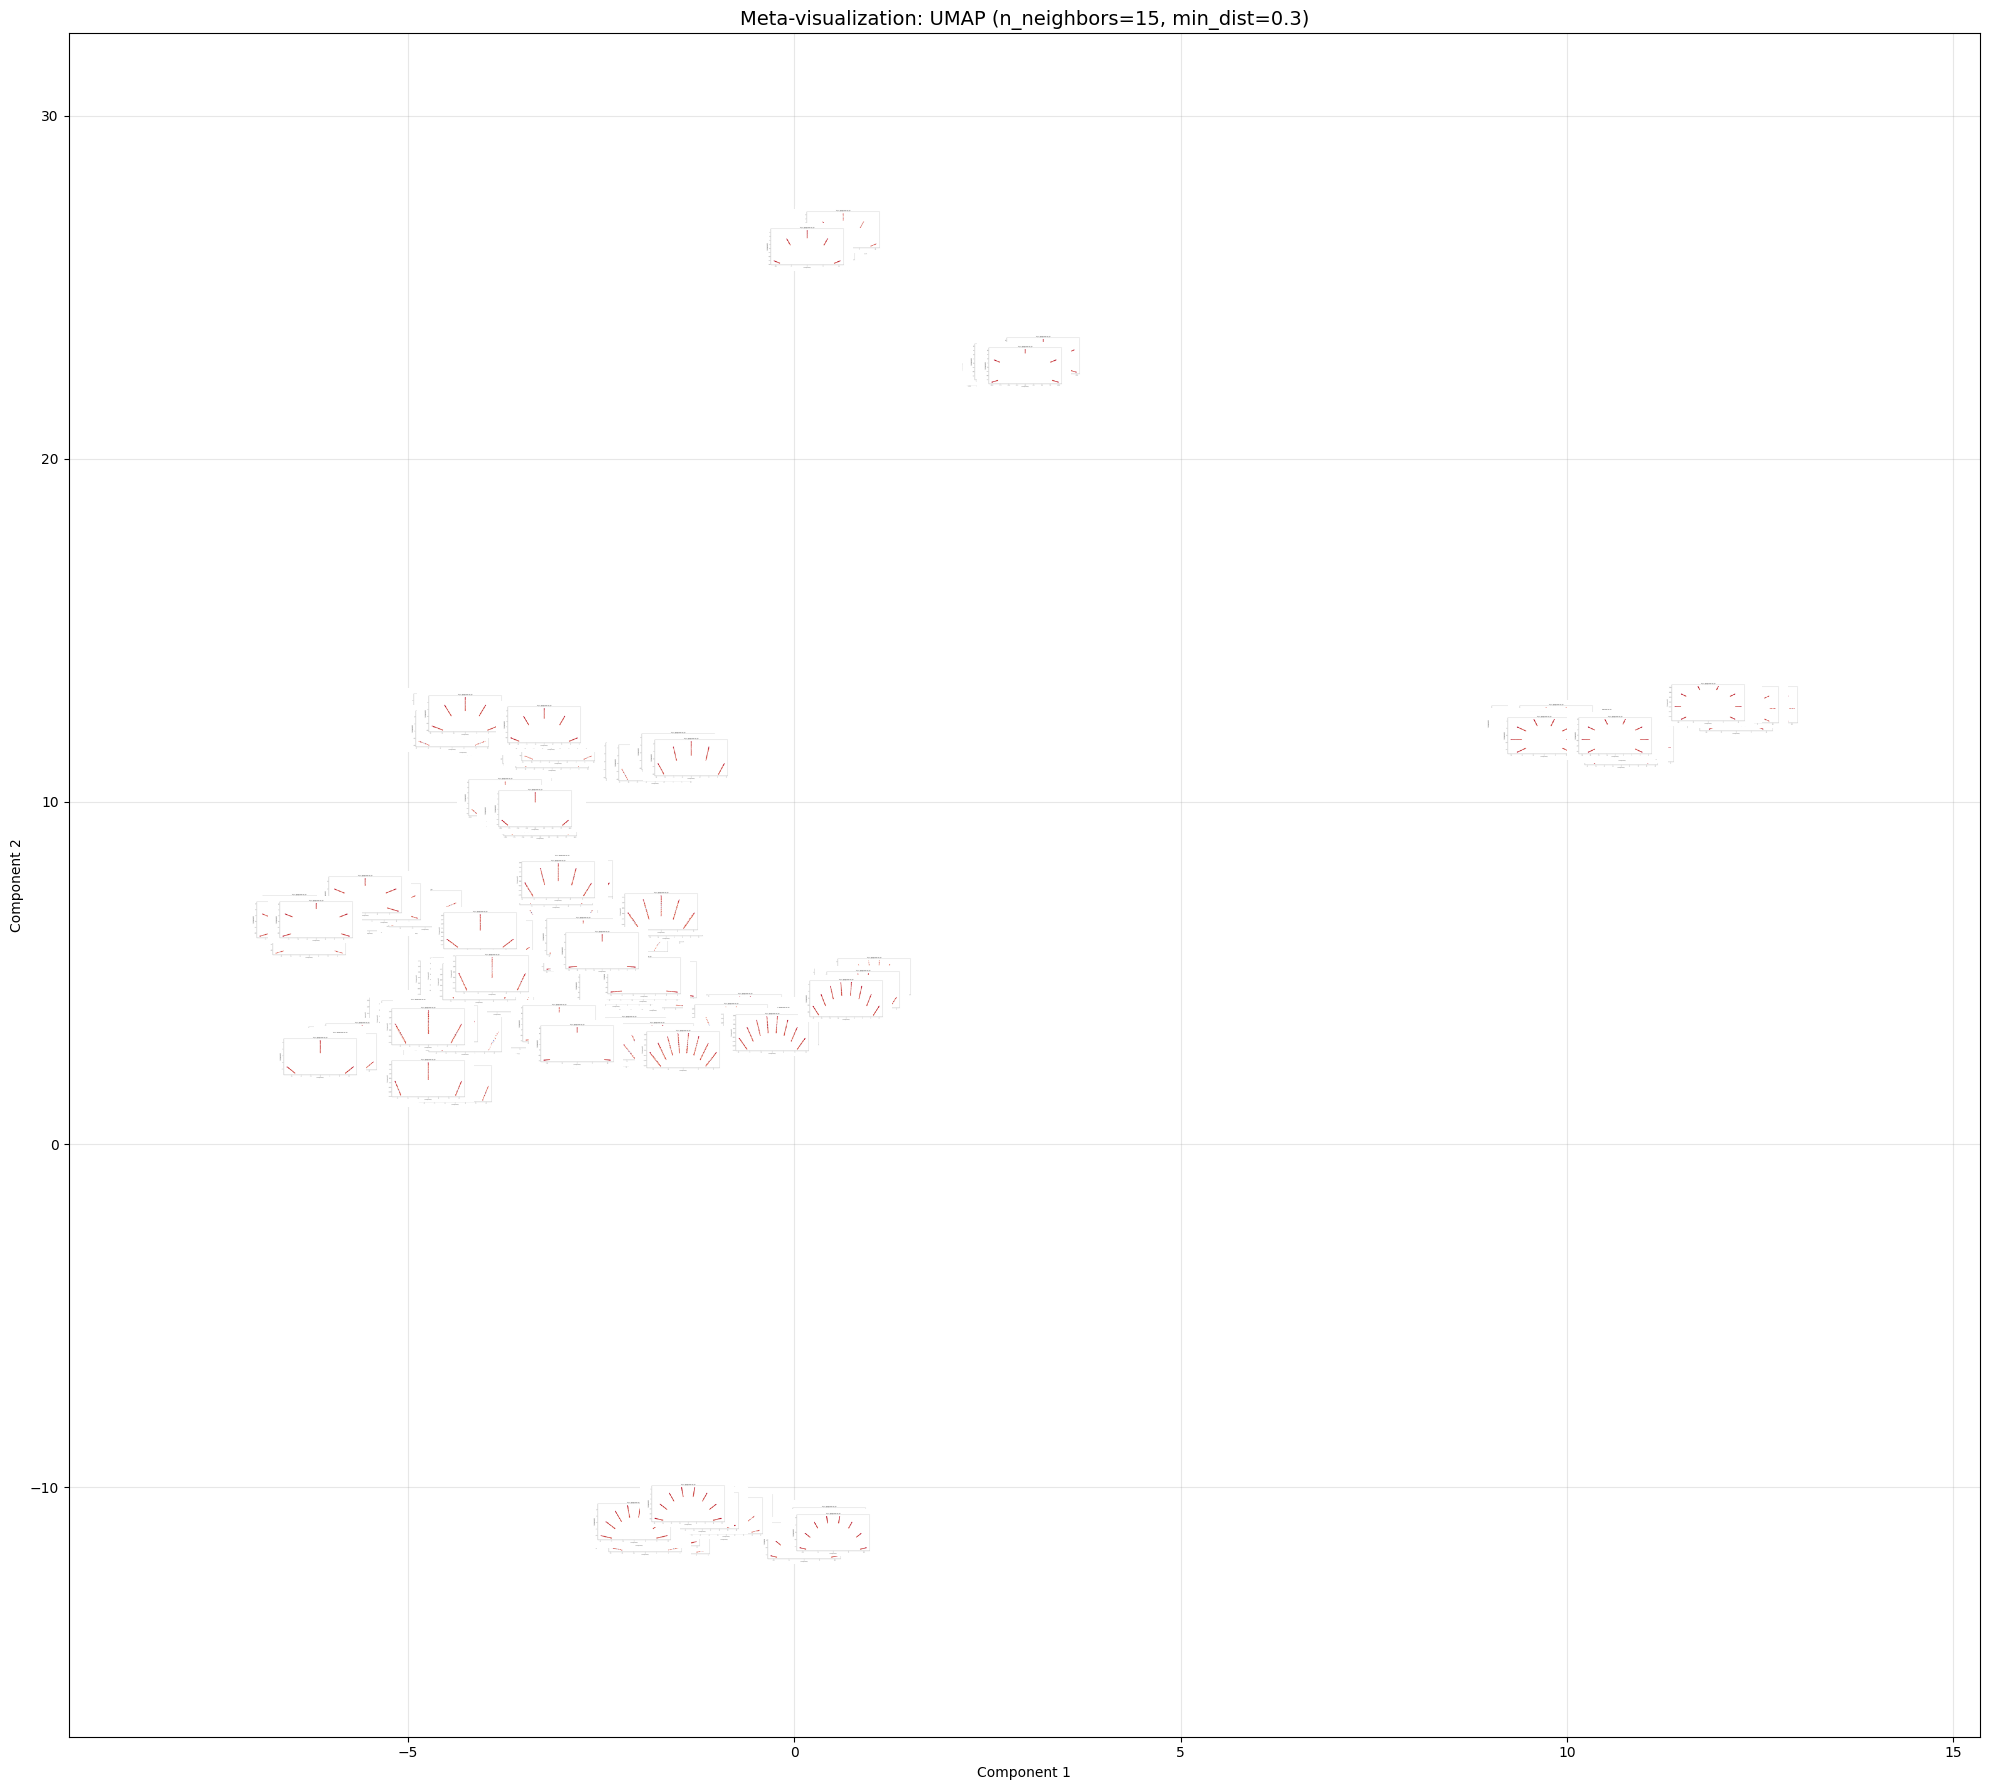

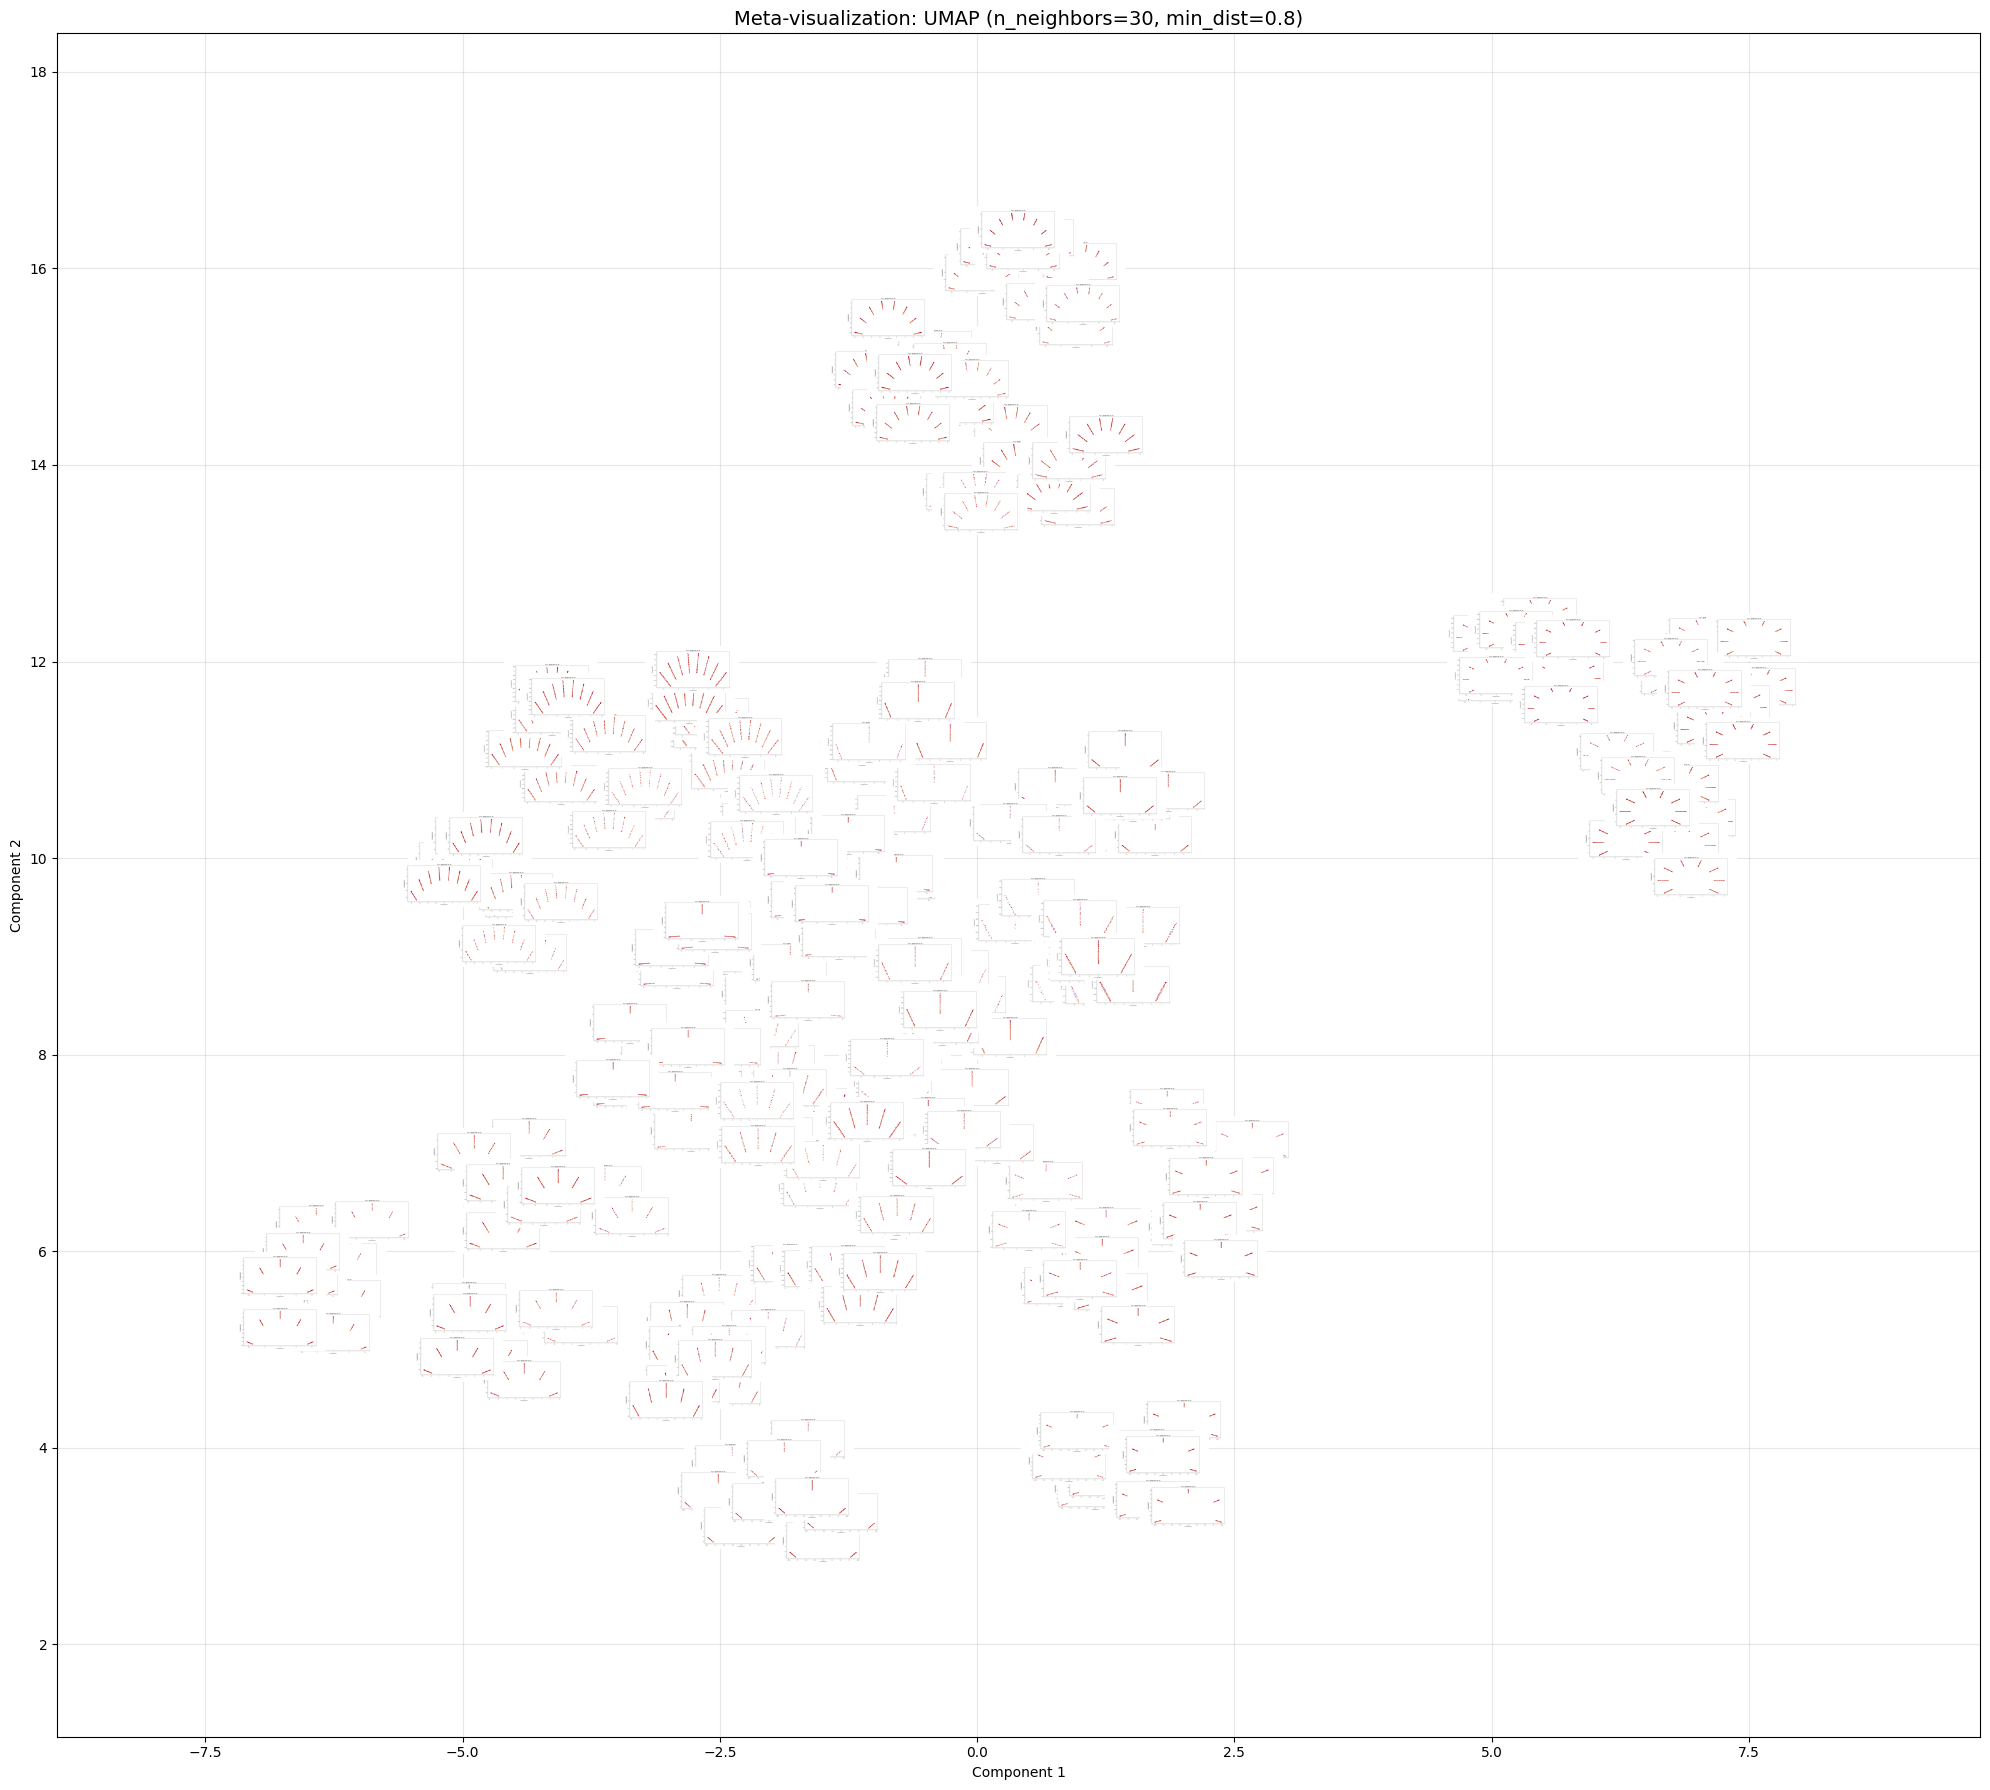

In [31]:
def plot_embedding_with_thumbnails(
    embedding_2d,
    filenames,
    title,
    save_path=None,
    zoom=0.25,
    thumbnail_size=(150, 150),
    figsize=(20, 18),
):
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
               s=20, c='lightgray', alpha=0.4, zorder=1)

    for i, fname in enumerate(filenames):
        try:
            img = Image.open(fname)
            img.thumbnail(thumbnail_size)
            imagebox = OffsetImage(np.array(img), zoom=zoom)
            ab = AnnotationBbox(
                imagebox,
                (embedding_2d[i, 0], embedding_2d[i, 1]),
                frameon=False,
                pad=0,
            )
            ax.add_artist(ab)
        except Exception as e:
            print(f"Skipping {fname}: {e}")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.grid(True, alpha=0.3)

    x_min, x_max = embedding_2d[:, 0].min(), embedding_2d[:, 0].max()
    y_min, y_max = embedding_2d[:, 1].min(), embedding_2d[:, 1].max()
    x_pad = (x_max - x_min) * 0.15
    y_pad = (y_max - y_min) * 0.15
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

# Generate meta-visualization for each method
for method_name, emb in embeddings.items():
    safe_name = (method_name.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '').replace(',', '_'))
    save_path = f"./meta/meta_{safe_name}.png"
    plot_embedding_with_thumbnails(
        embedding_2d=emb,
        filenames=filenames,
        title=f"Meta-visualization: {method_name}",
        save_path=save_path,
        zoom=0.45,
    )

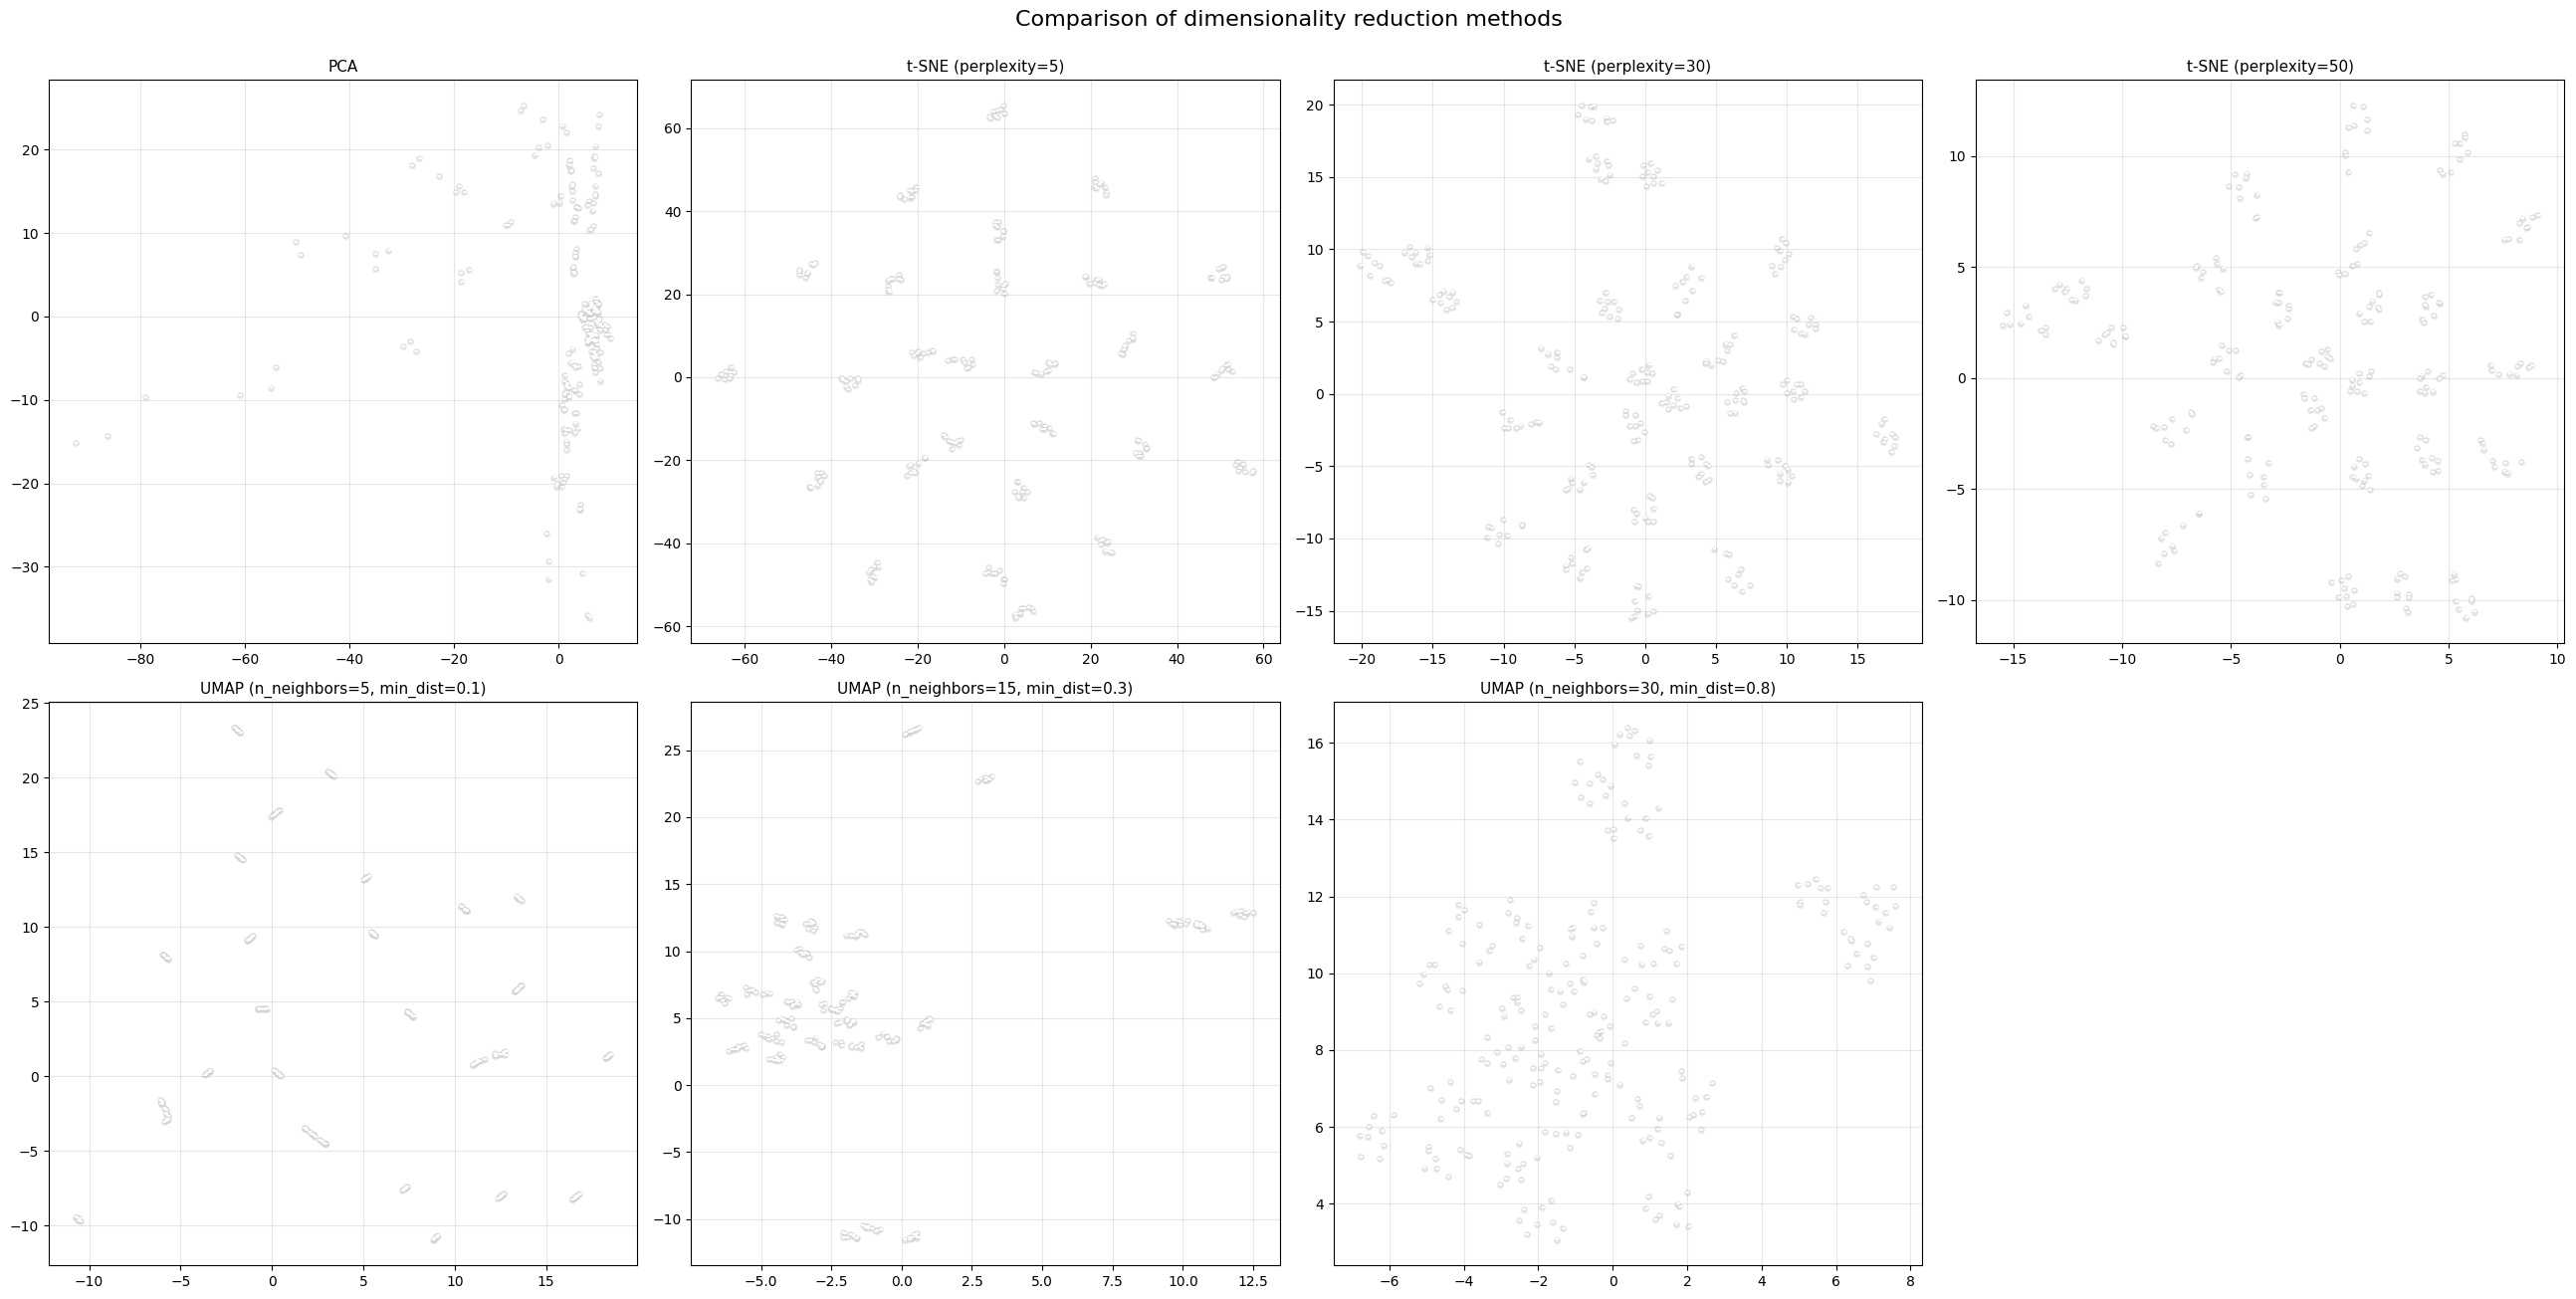

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(26, 13))
axes = axes.flatten()

for idx, (method_name, emb) in enumerate(embeddings.items()):
    ax = axes[idx]
    ax.scatter(emb[:, 0], emb[:, 1], s=15, c='lightgray', alpha=0.5)

    for i, fname in enumerate(filenames):
        try:
            img = Image.open(fname)
            img.thumbnail((60, 60))
            imagebox = OffsetImage(np.array(img), zoom=0.04)
            ab = AnnotationBbox(imagebox, (emb[i, 0], emb[i, 1]),
                                frameon=False, pad=0)
            ax.add_artist(ab)
        except Exception:
            pass

    ax.set_title(method_name, fontsize=11)
    ax.grid(True, alpha=0.3)

for ax in axes[len(embeddings):]:
    ax.axis('off')

plt.suptitle('Comparison of dimensionality reduction methods', fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig('./meta/meta_comparison_all_methods.png', dpi=120, bbox_inches='tight')
plt.show()

Analiza wizualizacji pokazuje, że trzy metody redukcji wymiarów dają wyraźnie różne rezultaty. Na wejściu obrazy mają głównie kształt „koła” lub „wachlarza” i różnią się przede wszystkim liczbą „ramion” (3, 5 lub 8), ich szerokością oraz kątem nachylenia. PCA daje najmniej czytelny wynik, ponieważ większość obrazków (około 60%) skupia się w jednej wąskiej kolumnie, a reszta rozciąga się w długi „ogon”. W praktyce oznacza to, że PCA dobrze rozróżnia głównie rozmiar obrazu, ale gubi subtelniejsze różnice w strukturze, przez co część informacji jest tracona.

t-SNE zachowuje się inaczej i tworzy lokalne grupy. Przy małej perpleksji powstaje dużo małych klastrów i widać głównie bardzo podobne obrazki obok siebie, ale bez ogólnej struktury. Przy średniej perpleksji pojawia się już bardziej czytelny podział, gdzie obrazy grupują się według liczby „ramion” i innych głównych cech. Przy dużej perpleksji grupy zaczynają się mieszać i obraz staje się bardziej rozmyty.

UMAP również silnie zależy od parametrów. Przy małych wartościach dane są rozproszone i nie tworzą sensownych grup, przy średnich większość punktów łączy się w jeden duży klaster, a przy większych parametrach pojawia się bardziej uporządkowana struktura z jednym głównym skupiskiem i mniejszymi podgrupami wewnątrz.

Wspólny wniosek jest taki, że najważniejsze cechy wpływające na wyniki wszystkich metod to liczba „ramion” (roll_density) oraz szerokość (width), ponieważ one najmocniej decydują o ogólnym kształcie obrazu i jego podobieństwie do innych. Pozostałe parametry mają mniejszy wpływ i powodują jedynie drobne zmiany wewnątrz już istniejących grup.